In [19]:
import os
import zipfile

ZIP_PATH = '/content/object_detection.h5.zip'
EXTRACT_TO = '.'
RENAMED_PATH = '/content/object_detection.h5'

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f'Zip file not found: {ZIP_PATH}')

try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        members = zf.namelist()
        zf.extractall(EXTRACT_TO)

    print(f'Unzipped: {ZIP_PATH}')
    print(f'Extracted files count: {len(members)}')
    print('Sample extracted entries:')
    for name in members[:10]:
        print(' -', name)

except zipfile.BadZipFile:
    # If it's not a zip file, assume it's the .h5 model itself with a wrong extension
    print(f"Error: '{ZIP_PATH}' is not a valid zip file. Attempting to rename it to '{RENAMED_PATH}' and proceed as a direct .h5 model.")
    if os.path.exists(RENAMED_PATH):
        # If the target name already exists, remove it before renaming to avoid errors
        os.remove(RENAMED_PATH)
        print(f"Removed existing file at '{RENAMED_PATH}' before renaming.")
    os.rename(ZIP_PATH, RENAMED_PATH)
    print(f"'{ZIP_PATH}' has been renamed to '{RENAMED_PATH}'. No files were unzipped.")
    # No members list to print if no unzipping occurred.

Error: '/content/object_detection.h5.zip' is not a valid zip file. Attempting to rename it to '/content/object_detection.h5' and proceed as a direct .h5 model.
Removed existing file at '/content/object_detection.h5' before renaming.
'/content/object_detection.h5.zip' has been renamed to '/content/object_detection.h5'. No files were unzipped.


In [20]:
import glob
import os

# Discover model files after extraction
# We prioritize the results/ folder if it exists, otherwise root
h5_candidates = glob.glob('./**/object_detection.h5', recursive=True)
onnx_candidates = glob.glob('/content/best.onnx', recursive=True)
pt_candidates = glob.glob('/content/best.pt', recursive=True) + glob.glob('/content/last.pt', recursive=True)

# Sort to prefer files in 'results/' or deeper structures which likely came from the zip
h5_candidates.sort(key=lambda x: os.path.getmtime(x), reverse=True)
onnx_candidates.sort(key=lambda x: 'results' in x, reverse=True)
pt_candidates.sort(key=lambda x: 'results' in x, reverse=True)

print('Detected model files:')
print(' - .h5 files:', len(h5_candidates))
for p in h5_candidates[:5]:
    print('    ', p)

print(' - best.onnx files:', len(onnx_candidates))
for p in onnx_candidates[:5]:
    print('    ', p)

print(' - YOLO .pt files:', len(pt_candidates))
for p in pt_candidates[:5]:
    print('    ', p)

Detected model files:
 - .h5 files: 1
     ./object_detection.h5
 - best.onnx files: 1
     /content/best.onnx
 - YOLO .pt files: 2
     /content/best.pt
     /content/last.pt


In [21]:
import tensorflow as tf
import os

# Filter candidates to ensure we are looking for the correct filename
h5_files = [f for f in h5_candidates if f.endswith('object_detection.h5')]

keras_model = None
if not h5_files:
    print('❌ No object_detection.h5 found. Please check extraction.')
else:
    # Try candidates in order
    for keras_path in h5_files:
        print(f'Attempting to load Keras model from: {keras_path}')
        try:
            # Lambda layers require safe_mode=False
            keras_model = tf.keras.models.load_model(keras_path, safe_mode=False)
            print(f'✅ Successfully loaded Keras model from: {keras_path}')
            break # Exit loop if successful
        except EOFError:
            print(f'❌ Corruption Error (EOFError) for {keras_path}. This file might be incomplete.')
        except Exception as e:
            print(f'❌ Could not load {keras_path}: {e}')

if keras_model is None:
    print("⚠️ Keras model load failed across all candidates. YOLO models might still work!")
else:
    print('Keras model type:', type(keras_model))

Attempting to load Keras model from: ./object_detection.h5
❌ Could not load ./object_detection.h5: Unable to synchronously open file (file signature not found)
⚠️ Keras model load failed across all candidates. YOLO models might still work!


In [22]:
import cv2
import os

# Load YOLO ONNX model used in the main notebook
yolo_net = None
if onnx_candidates:
    # Use the best candidate found in the scan
    yolo_onnx_path = onnx_candidates[0]
    try:
        yolo_net = cv2.dnn.readNetFromONNX(yolo_onnx_path)
        yolo_net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
        yolo_net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)
        print('✅ Successfully loaded YOLO ONNX model from:', yolo_onnx_path)
    except Exception as e:
        print('❌ Error loading ONNX model:', e)
else:
    print('⚠️ No best.onnx model found in workspace. Scanning for alternatives...')
    # Last ditch attempt at specific path
    alt_path = './results/yolov5/runs/train/Model/weights/best.onnx'
    if os.path.exists(alt_path):
        try:
            yolo_net = cv2.dnn.readNetFromONNX(alt_path)
            print('✅ Found and loaded model at specific path:', alt_path)
        except:
             print('❌ Specific path failed too.')
    else:
        print('❌ Could not find model file.')

✅ Successfully loaded YOLO ONNX model from: /content/best.onnx


In [23]:
# Optional: load YOLO .pt weights if torch + local yolov5 repo are available
yolo_pt_model = None
if pt_candidates:
    try:
        import torch
        repo_candidates = glob.glob('./**/yolov5/hubconf.py', recursive=True)
        if repo_candidates:
            yolo_repo_dir = os.path.dirname(repo_candidates[0])
            pt_path = pt_candidates[0]
            yolo_pt_model = torch.hub.load(yolo_repo_dir, 'custom', path=pt_path, source='local', force_reload=False)
            print('Loaded YOLO PT model from:', pt_path)
        else:
            print('Found .pt weights but local yolov5 repo was not found; skipped torch.hub loading.')
    except Exception as e:
        print('Could not load .pt model (optional step):', e)
else:
    print('No .pt weights found.')

Found .pt weights but local yolov5 repo was not found; skipped torch.hub loading.


In [24]:
print('--- Final Load Status ---')
print('Keras model loaded:', keras_model is not None)
print('YOLO ONNX loaded:', yolo_net is not None)
print('YOLO PT loaded (optional):', yolo_pt_model is not None)

--- Final Load Status ---
Keras model loaded: False
YOLO ONNX loaded: True
YOLO PT loaded (optional): False


In [25]:
!pip install pytesseract

In [26]:
import re
import cv2
import numpy as np
import pytesseract as pt
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image
import io

def get_detections(img, net, input_width=640, input_height=640):
    image = img.copy()
    row, col, d = image.shape
    max_rc = max(row, col)
    input_image = np.zeros((max_rc, max_rc, 3), dtype=np.uint8)
    input_image[0:row, 0:col] = image
    blob = cv2.dnn.blobFromImage(input_image, 1/255, (input_width, input_height), swapRB=True, crop=False)
    net.setInput(blob)
    preds = net.forward()
    return input_image, preds[0]

def non_maximum_supression(input_image, detections, conf_threshold=0.3, nms_threshold=0.3):
    boxes = []
    confidences = []

    image_w, image_h = input_image.shape[:2]
    # Scaling factors to map detections back to the actual padded image
    x_factor = image_h/640
    y_factor = image_w/640

    for i in range(len(detections)):
        row = detections[i]
        confidence = row[4]
        if confidence > conf_threshold:
            # YOLOv5 output: [cx, cy, w, h, confidence, class1_score, class2_score...]
            class_score = row[5] # Score for 'licence' class
            if class_score > 0.25:
                # Row 0:4 are center x, center y, width, height
                cx, cy, w, h = row[0:4]
                left = int((cx - 0.5*w)*x_factor)
                top = int((cy - 0.5*h)*y_factor)
                width = int(w*x_factor)
                height = int(h*y_factor)
                boxes.append([left, top, width, height])
                confidences.append(confidence)

    index = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)
    return boxes, confidences, index

def perform_detection(img_array):
    if yolo_net is None:
        print("❌ YOLO model not loaded!")
        return

    # 1. Prediction using YOLO ONNX
    input_image, detections = get_detections(img_array, yolo_net)
    boxes, confidences, index = non_maximum_supression(input_image, detections)

    original = img_array.copy()
    h, w, _ = original.shape

    if len(index) > 0:
        for i in index.flatten():
            x, y, bw, bh = boxes[i]
            # 2. Coordinate sanity checks (must be within original image)
            xmin, ymin = max(0, x), max(0, y)
            xmax, ymax = min(w, x + bw), min(h, y + bh)

            # 3. Crop ROI
            plate_crop = original[ymin:ymax, xmin:xmax]

            # 4. Image Preprocessing for OCR
            if plate_crop.size > 0:
                gray_crop = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
                # Resize for better OCR extraction
                gray_crop = cv2.resize(gray_crop, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
                blur_crop = cv2.bilateralFilter(gray_crop, 11, 17, 17)
                _, thresh_crop = cv2.threshold(blur_crop, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

                # 5. Extract Text using Pytesseract
                # --psm 7 is usually better for single lines of text like license plates
                config = '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
                raw_text = pt.image_to_string(thresh_crop, config=config)
                plate_text = re.sub(r'[^A-Z0-9]', '', raw_text.upper()).strip()

                # Fallback to --psm 11 (sparse text) if --psm 7 fails
                if not plate_text:
                    config_alt = '--psm 11 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
                    raw_text = pt.image_to_string(thresh_crop, config=config_alt)
                    plate_text = re.sub(r'[^A-Z0-9]', '', raw_text.upper()).strip()

                if not plate_text: plate_text = "NO PLATE TEXT"
            else:
                plate_text = "NO BBOX FOUND"
                thresh_crop = np.zeros((10,10), dtype=np.uint8)

            # 6. Labeling & Visualization
            cv2.rectangle(original, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)
            # Use dynamic font scale for visibility
            font_scale = max(0.8, w/800)
            cv2.putText(original, f"{plate_text}", (xmin, max(30, ymin - 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 255, 0), 3)

            print(f"✅ Prediction: [{plate_text}] (Confidence Score: {confidences[i]:.2f})")

            # Show the Crop and what the OCR "sees"
            plt.figure(figsize=(10,4))
            plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB)); plt.title("Plate ROI")
            plt.subplot(1,2,2); plt.imshow(thresh_crop, cmap='gray'); plt.title("OCR Input Pattern")
            plt.show()

        # Show Full Image
        plt.figure(figsize=(12,8))
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        plt.title("Full ANPR Pipeline Visualization")
        plt.axis('off')
        plt.show()
    else:
        print("❌ YOLO model could not detect a license plate in this image.")
        # Ensure the image is shown even on failure context
        plt.figure(figsize=(10,6))
        plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
        plt.title("Analysis Result: No Plate Detected")
        plt.axis('off')
        plt.show()

print("ANPR Detection functions synchronized with original logic.")


ANPR Detection functions synchronized with original logic.


Upload an image below to start detection:


FileUpload(value={}, accept='image/*', description='Upload')

Output()

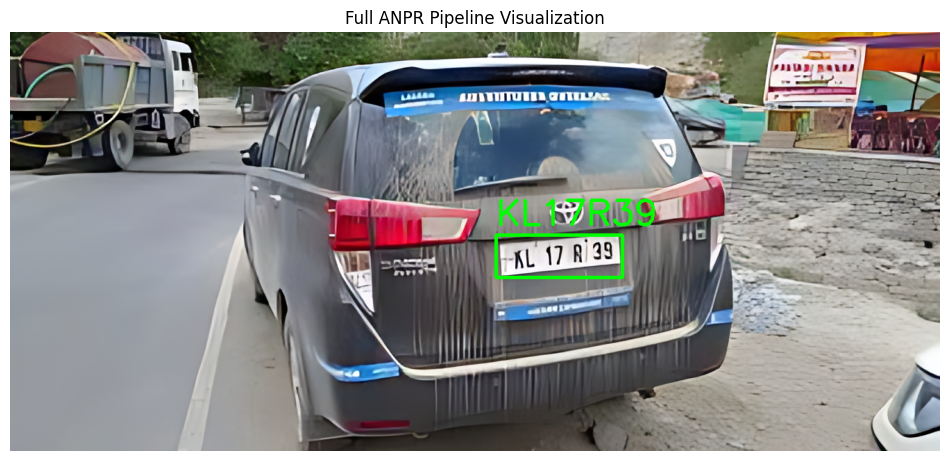

In [28]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create UI Elements
upload_btn = widgets.FileUpload(
    accept='image/*', # Accept all image formats
    multiple=False    # Single file upload
)
output = widgets.Output()

def on_value_change(change):
    with output:
        clear_output()
        if not upload_btn.value:
            return

        # Get uploaded image file content
        file_name = next(iter(upload_btn.value))
        file_content = upload_btn.value[file_name]['content']

        # Convert to numpy array via Image
        img_pil = Image.open(io.BytesIO(file_content)).convert('RGB')
        img_array = np.array(img_pil)

        # OpenCv expects BGR, while PIL uses RGB
        img_cv = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

        print(f"Processing image: {file_name}")
        perform_detection(img_cv)

# Observe value changes in FileUpload widget
upload_btn.observe(on_value_change, names='value')

print("Upload an image below to start detection:")
display(upload_btn, output)

### Popular Open-Source OCR Models for Robust Character Recognition:

1.  **Tesseract OCR:**
    *   **Description:** Developed by Google, Tesseract is one of the most widely used open-source OCR engines. It's highly configurable and supports a large number of languages. It performs well with clear images but can be finetuned or pre-processed for challenging conditions.
    *   **Strengths:** Mature, robust, actively maintained, supports many languages, good for a variety of tasks.
    *   **Considerations:** Can sometimes struggle with highly distorted or low-resolution text without proper image preprocessing or fine-tuning.

2.  **PaddleOCR:**
    *   **Description:** Developed by Baidu, PaddleOCR is a powerful and comprehensive OCR toolkit that includes highly accurate text detection and recognition models. It's known for its strong performance on diverse datasets and robustness to various image conditions (e.g., rotation, blur, complex backgrounds).
    *   **Strengths:** High accuracy, strong performance on complex images, supports multiple languages, well-documented, includes both detection and recognition models.
    *   **Considerations:** Can be more resource-intensive than Tesseract.

3.  **EasyOCR:**
    *   **Description:** A general-purpose OCR library that supports over 80 languages. It's designed to be easy to use and provides a simple API for both text detection and recognition. It's built with PyTorch.
    *   **Strengths:** Extremely easy to use, supports many languages out-of-the-box, good for quick integration and prototyping.
    *   **Considerations:** May not offer the same level of customization or fine-tuning options as Tesseract or PaddleOCR.

4.  **Keras-OCR / TensorFlow OCR:**
    *   **Description:** While not a single monolithic project, there are numerous open-source OCR implementations built on Keras/TensorFlow. Keras-OCR, for instance, is a package that includes a full OCR pipeline (detection and recognition) and pre-trained models. These deep learning-based approaches are very powerful for extracting text from images.
    *   **Strengths:** Leverages state-of-the-art deep learning architectures, highly accurate, flexible for custom model development.
    *   **Considerations:** Requires more understanding of deep learning and model architecture for customization; can be more computationally demanding.

5.  **TRBA (Transformer-based Recognition with Bottleneck Attention):**
    *   **Description:** An advanced deep learning model specifically for scene text recognition (recognition of text in natural images). It leverages Transformer architecture, which has shown excellent performance in sequence-to-sequence tasks like text recognition. It often forms the recognition component within larger OCR pipelines.
    *   **Strengths:** State-of-the-art accuracy for scene text, handles varying text orientations and styles well.
    *   **Considerations:** Typically integrated as part of a larger OCR system; requires a deep learning framework like PyTorch or TensorFlow.

In [36]:
print("Installing EasyOCR. This might take a few minutes...")
!pip install -q easyocr==1.7.1

# Also install OpenCV-Python if not already present
!pip install -q opencv-python-headless

print("Installation complete.")

Installing EasyOCR. This might take a few minutes...
Installation complete.


In [38]:
import easyocr
import numpy as np # Already imported in O6eoci9ym0kq, but good to ensure


# Initialize EasyOCR (takes some time to load models)
print("Initializing EasyOCR model...")
try:
    ocr_easy = easyocr.Reader(['en'])
    print("✅ EasyOCR initialized.")
except Exception as e:
    print(f"❌ Failed to initialize EasyOCR: {e}")
    ocr_easy = None

print("OCR models initialization complete.")

Initializing EasyOCR model...
✅ EasyOCR initialized.
OCR models initialization complete.


In [39]:
import re
import cv2
import numpy as np
import pytesseract as pt
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image
import io
import pandas as pd # Import pandas for tabular output

def get_detections(img, net, input_width=640, input_height=640):
    image = img.copy()
    row, col, d = image.shape
    max_rc = max(row, col)
    input_image = np.zeros((max_rc, max_rc, 3), dtype=np.uint8)
    input_image[0:row, 0:col] = image
    blob = cv2.dnn.blobFromImage(input_image, 1/255, (input_width, input_height), swapRB=True, crop=False)
    net.setInput(blob)
    preds = net.forward()
    return input_image, preds[0]

def non_maximum_supression(input_image, detections, conf_threshold=0.3, nms_threshold=0.3):
    boxes = []
    confidences = []

    image_w, image_h = input_image.shape[:2]
    # Scaling factors to map detections back to the actual padded image
    x_factor = image_h/640
    y_factor = image_w/640

    for i in range(len(detections)):
        row = detections[i]
        confidence = row[4]
        if confidence > conf_threshold:
            # YOLOv5 output: [cx, cy, w, h, confidence, class1_score, class2_score...]
            class_score = row[5] # Score for 'licence' class
            if class_score > 0.25:
                # Row 0:4 are center x, center y, width, height
                cx, cy, w, h = row[0:4]
                left = int((cx - 0.5*w)*x_factor)
                top = int((cy - 0.5*h)*y_factor)
                width = int(w*x_factor)
                height = int(h*y_factor)
                boxes.append([left, top, width, height])
                confidences.append(confidence)

    index = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)
    return boxes, confidences, index

def run_ocr_models(processed_image):
    results = []

    # Tesseract OCR
    tesseract_config_psm7 = '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
    tesseract_raw_text = pt.image_to_string(processed_image, config=tesseract_config_psm7)
    tesseract_text = re.sub(r'[^A-Z0-9]', '', tesseract_raw_text.upper()).strip()
    if not tesseract_text:
        tesseract_config_psm11 = '--psm 11 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
        tesseract_raw_text = pt.image_to_string(processed_image, config=tesseract_config_psm11)
        tesseract_text = re.sub(r'[^A-Z0-9]', '', tesseract_raw_text.upper()).strip()
    results.append({'Model': 'Tesseract', 'Detected Text': tesseract_text if tesseract_text else 'NO TEXT'})

    # EasyOCR
    if 'ocr_easy' in globals() and ocr_easy is not None:
        easy_result_raw = ocr_easy.readtext(processed_image)
        easy_text = ''
        for (bbox, text, score) in easy_result_raw:
            easy_text += text + ' '
        easy_text = re.sub(r'[^A-Z0-9]', '', easy_text.upper()).strip()
        results.append({'Model': 'EasyOCR', 'Detected Text': easy_text if easy_text else 'NO TEXT'})
    else:
        results.append({'Model': 'EasyOCR', 'Detected Text': 'Model Not Loaded'})

    return pd.DataFrame(results)

def perform_detection(img_array):
    if yolo_net is None:
        print("❌ YOLO model not loaded!")
        return

    # 1. Prediction using YOLO ONNX
    input_image, detections = get_detections(img_array, yolo_net)
    boxes, confidences, index = non_maximum_supression(input_image, detections)

    original = img_array.copy()
    h, w, _ = original.shape

    if len(index) > 0:
        for i in index.flatten():
            x, y, bw, bh = boxes[i]
            # 2. Coordinate sanity checks (must be within original image)
            xmin, ymin = max(0, x), max(0, y)
            xmax, ymax = min(w, x + bw), min(h, y + bh)

            # 3. Crop ROI
            plate_crop = original[ymin:ymax, xmin:xmax]

            # 4. Image Preprocessing for OCR
            if plate_crop.size > 0:
                gray_crop = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
                # Resize for better OCR extraction
                gray_crop = cv2.resize(gray_crop, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
                blur_crop = cv2.bilateralFilter(gray_crop, 11, 17, 17)
                _, thresh_crop = cv2.threshold(blur_crop, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

                # 5. Run Multiple OCR Models
                print(f"✅ License plate detected with confidence: {confidences[i]:.2f}")
                print("Running multiple OCR models...")
                ocr_comparison_df = run_ocr_models(thresh_crop)
                print("OCR Results Comparison:")
                display(ocr_comparison_df) # Display tabular output

                # 6. Labeling & Visualization (using Tesseract's result for display consistency)
                # Prioritize Tesseract for display if available, otherwise EasyOCR
                plate_text_for_display = "NO PLATE TEXT"
                if not ocr_comparison_df.empty:
                    tesseract_row = ocr_comparison_df[ocr_comparison_df['Model'] == 'Tesseract']
                    easy_row = ocr_comparison_df[ocr_comparison_df['Model'] == 'EasyOCR']

                    if not tesseract_row.empty and tesseract_row['Detected Text'].iloc[0] != 'NO TEXT':
                        plate_text_for_display = tesseract_row['Detected Text'].iloc[0]
                    elif not easy_row.empty and easy_row['Detected Text'].iloc[0] != 'NO TEXT' and easy_row['Detected Text'].iloc[0] != 'Model Not Loaded':
                        plate_text_for_display = easy_row['Detected Text'].iloc[0]


                cv2.rectangle(original, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)
                # Use dynamic font scale for visibility
                font_scale = max(0.8, w/800)
                cv2.putText(original, f"{plate_text_for_display}", (xmin, max(30, ymin - 15)),
                            cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 255, 0), 3)

                # Show the Crop and what the OCR "sees"
                plt.figure(figsize=(10,4))
                plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB)); plt.title("Plate ROI")
                plt.subplot(1,2,2); plt.imshow(thresh_crop, cmap='gray'); plt.title("OCR Input Pattern")
                plt.show()
            else:
                print("⚠️ Detected bounding box was empty after cropping. No OCR performed.")
                thresh_crop = np.zeros((10,10), dtype=np.uint8) # Placeholder for visualization if crop is empty

        # Show Full Image
        plt.figure(figsize=(12,8))
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        plt.title("Full ANPR Pipeline Visualization")
        plt.axis('off')
        plt.show()
    else:
        print("❌ YOLO model could not detect a license plate in this image.")
        # Ensure the image is shown even on failure context
        plt.figure(figsize=(10,6))
        plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
        plt.title("Analysis Result: No Plate Detected")
        plt.axis('off')
        plt.show()

print("ANPR Detection functions updated to exclude PaddleOCR.")

ANPR Detection functions updated to exclude PaddleOCR.


In [41]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io
import cv2
import numpy as np

# Create UI Elements
upload_btn = widgets.FileUpload(
    accept='image/*', # Accept all image formats
    multiple=False    # Single file upload
)
output = widgets.Output()

def on_value_change(change):
    with output:
        clear_output()
        if not upload_btn.value:
            return

        # Get uploaded image file content
        file_name = next(iter(upload_btn.value))
        file_content = upload_btn.value[file_name]['content']

        # Convert to numpy array via Image
        img_pil = Image.open(io.BytesIO(file_content)).convert('RGB')
        img_array = np.array(img_pil)

        # OpenCv expects BGR, while PIL uses RGB
        img_cv = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

        print(f"Processing image: {file_name}")
        # Call the updated perform_detection function
        perform_detection(img_cv)

# Observe value changes in FileUpload widget
upload_btn.observe(on_value_change, names='value')

print("Upload an image below to start detection and OCR comparison:")
display(upload_btn, output)

Upload an image below to start detection and OCR comparison:


FileUpload(value={}, accept='image/*', description='Upload')

Output()

In [42]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io
import cv2
import numpy as np

# Create UI Elements
upload_btn = widgets.FileUpload(
    accept='image/*', # Accept all image formats
    multiple=False    # Single file upload
)
output = widgets.Output()

def on_value_change(change):
    with output:
        clear_output()
        if not upload_btn.value:
            return

        # Get uploaded image file content
        file_name = next(iter(upload_btn.value))
        file_content = upload_btn.value[file_name]['content']

        # Convert to numpy array via Image
        img_pil = Image.open(io.BytesIO(file_content)).convert('RGB')
        img_array = np.array(img_pil)

        # OpenCv expects BGR, while PIL uses RGB
        img_cv = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

        print(f"Processing image: {file_name}")
        # Call the updated perform_detection function
        perform_detection(img_cv)

# Observe value changes in FileUpload widget
upload_btn.observe(on_value_change, names='value')

print("Upload an image below to start detection and OCR comparison:")
display(upload_btn, output)

Upload an image below to start detection and OCR comparison:


FileUpload(value={}, accept='image/*', description='Upload')

Output()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io
import cv2
import numpy as np

def start_anpr_pipeline_ui():
    """
    Sets up and displays the image upload widget to initiate the ANPR pipeline.
    The pipeline (detection + multi-OCR comparison) runs automatically when an image is uploaded.
    """
    print("Initializing ANPR UI. Upload an image below to start detection and OCR comparison:")

    # Create UI Elements
    upload_btn = widgets.FileUpload(
        accept='image/*', # Accept all image formats
        multiple=False    # Single file upload
    )
    output = widgets.Output()

    def on_value_change(change):
        with output:
            clear_output()
            if not upload_btn.value:
                return

            # Get uploaded image file content
            file_name = next(iter(upload_btn.value))
            file_content = upload_btn.value[file_name]['content']

            # Convert to numpy array via Image
            img_pil = Image.open(io.BytesIO(file_content)).convert('RGB')
            img_array = np.array(img_pil)

            # OpenCv expects BGR, while PIL uses RGB
            img_cv = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

            print(f"Processing image: {file_name}")
            # Call the updated perform_detection function
            perform_detection(img_cv)

    # Observe value changes in FileUpload widget
    upload_btn.observe(on_value_change, names='value')

    display(upload_btn, output)

print("The 'start_anpr_pipeline_ui()' function is now defined.")

In [ ]:
# Call the function to activate the ANPR pipeline UI
start_anpr_pipeline_ui()